<a href="https://colab.research.google.com/github/maha1606-gitoctocat/Python-Projects/blob/main/Python_for_Data_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Task 1: Import Required Libraries**

In [ ]:
# Task 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load Dataset
from google.colab import drive

drive.mount('/content/drive')

import pandas as pd

file_path = '/content/drive/MyDrive/social_media_engagement_5000.csv'
df = pd.read_csv(file_path)
print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      user_id   age  gender    country  post_id post_type post_category  \
0       25795  43.0  Female     Brazil   496713     image       fitness   
1       10860  33.0    Male     Brazil   157326      reel          food   
2       86820  32.0  Female         UK   109864      text          food   
3       64886  51.0   Other     France   848877      text       fitness   
4       16265  34.0   Other         UK   449706     image       fitness   
...       ...   ...     ...        ...      ...       ...           ...   
4995    59500  44.0    Male  Australia   441541     video     education   
4996    22100  38.0   Other        UAE   677076      reel     education   
4997    67021  63.0  Female        USA   273595      text        travel   
4998    29800  13.0  Female    Germany   785644     video       fitness   
4999    73400  54.0   Other      Japan   71225

# **Task 2: Data Cleaning**

In [ ]:
# Missing Values
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
# Fill Numerical Missing Values
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2344/2917005808.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
# Missing Values
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
user_id               0
age                   0
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes                 0
comments              0
shares                0
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
# Fill Categorical Missing Values
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2344/2502185905.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
# Missing Values
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [ ]:
# Remove Duplicates
df.drop_duplicates(inplace=True)


In [ ]:
# Convert Date
df["posted_at"] = pd.to_datetime(df["posted_at"])

/tmp/ipykernel_2344/338077645.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["posted_at"] = pd.to_datetime(df["posted_at"])


In [ ]:
# Show detailed info (data types, null values, memory usage)
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verifie

In [ ]:
# Standardize Gender
df["gender"] = df["gender"].str.title()

In [ ]:
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
# Correct Negative Values
for col in ["likes","comments","shares"]:
    df[col] = df[col].clip(lower=0)

In [ ]:
# Hashtag Count
df["hashtag_count"] = df["hashtags"].fillna("").apply(
    lambda x: len(str(x).split())
)

In [ ]:
# Clean Sentiment
df["sentiment"] = df["sentiment"].str.lower().str.strip()

print(f"\nFinal Dataset Shape : {df.shape}")


Final Dataset Shape : (5000, 20)


## **Task 3: Data Exploration**

In [ ]:
# Show first 5 rows of dataset
print("First 5 rows:")
print(df.head())

First 5 rows:
   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0     354.0  1157.0            5726             44650 2022-12-17   
1    2606.0  1807.0            5947             80216 2023-06-02   
2     344.0   955.0            6946             44858 2023-05-07   
3    1083.0  1049.0             229             70455 2023-02-12   
4    2735.0  1300.0            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        Fals

In [ ]:
# Show last 5 rows of dataset
print("Last 5 rows:")
print(df.tail())

Last 5 rows:
      user_id   age  gender    country  post_id post_type post_category  \
4995    59500  44.0    Male  Australia   441541     video     education   
4996    22100  38.0   Other        UAE   677076      reel     education   
4997    67021  63.0  Female        USA   273595      text        travel   
4998    29800  13.0  Female    Germany   785644     video       fitness   
4999    73400  54.0   Other      Japan   712252      text        travel   

        likes  comments  shares  watch_time_sec  impression_count  posted_at  \
4995  16210.0    2013.0  1837.0            6190             42977 2022-06-25   
4996  16924.0    2734.0  1583.0            7764             34196 2022-11-18   
4997  13487.0    1497.0   167.0            7466             23680 2023-04-06   
4998  16894.0    1289.0  1713.0            4991             89013 2022-05-16   
4999  14830.0     503.0  1798.0            3743             14234 2023-03-04   

      follower_count  is_verified device_type sentiment

In [ ]:
# Show shape of dataset (rows, columns)
print("Shape of dataset (rows, columns):")
print(df.shape)

Shape of dataset (rows, columns):
(5000, 20)


In [ ]:
# Show column names in dataset
print("Column names:")
print(df.columns)

Column names:
Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')


In [ ]:
# Show detailed info (data types, null values, memory usage)
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verifie

In [ ]:
# Show data types of each column
print("Data types of columns:")
print(df.dtypes)

Data types of columns:
user_id                      int64
age                        float64
gender                      object
country                     object
post_id                      int64
post_type                   object
post_category               object
likes                      float64
comments                   float64
shares                     float64
watch_time_sec               int64
impression_count             int64
posted_at           datetime64[ns]
follower_count               int64
is_verified                   bool
device_type                 object
sentiment                   object
hashtags                    object
engagement_rate            float64
hashtag_count                int64
dtype: object


In [ ]:
# Show summary statistics for numeric columns
# Includes count, mean, std, min, 25%, 50%, 75%, max
print("Statistical summary:")
print(df.describe())

Statistical summary:
            user_id          age        post_id         likes     comments  \
count   5000.000000  5000.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.440400  548042.909000  10106.997400  1502.039800   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   5235.000000   792.000000   
50%    54374.500000    38.000000  548077.500000  10105.500000  1497.000000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    26090.370121    14.687151  260646.957267   5702.293017   856.393312   

          shares  watch_time_sec  impression_count  \
count  5000.0000     5000.000000       5000.000000   
mean   1002.9106     4014.503200      50013.732800   
min       0.0000        0.000000        105.000000   
25%     511.0000     2017.750000      24988.250000   
50%   

In [ ]:
# Analyze categorical distributions using value_counts(), unique(), and nunique().
print("\nvalue_counts")
print(df["gender"].value_counts())

print("\nunique")
print(df["country"].nunique())

print("\nunique")
print(df["post_type"].unique())


value_counts
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

unique
10

unique
['image' 'reel' 'text' 'video']


In [ ]:
# Correlation Matrix
corr = df.select_dtypes(include=np.number).corr()
print(corr)

                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006688  0.020051  0.025811 -0.033395  0.013763   
age              -0.006688  1.000000 -0.013153 -0.036322 -0.007284  0.013871   
post_id           0.020051 -0.013153  1.000000  0.014526 -0.010540  0.001846   
likes             0.025811 -0.036322  0.014526  1.000000 -0.018421  0.004712   
comments         -0.033395 -0.007284 -0.010540 -0.018421  1.000000  0.006142   
shares            0.013763  0.013871  0.001846  0.004712  0.006142  1.000000   
watch_time_sec   -0.016847  0.005542  0.018374  0.008710 -0.016351  0.014658   
impression_count  0.015326  0.013322 -0.007709  0.007952 -0.009395 -0.005204   
follower_count    0.010124 -0.024894 -0.002844 -0.022982 -0.011733 -0.010783   
engagement_rate  -0.004282  0.008039  0.010139  0.093520  0.000051  0.021724   
hashtag_count    -0.013692  0.007173  0.007344 -0.002190 -0.015230  0.013379   

                  watch_time_sec  impre

In [ ]:
# GroupBy

print("\nAverage Likes by Post Type")
print(df.groupby("post_type")["likes"].mean())

print("\nAverage Impressions by Country")
print(df.groupby("country")["impression_count"].mean())


Average Likes by Post Type
post_type
image    10104.865277
reel     10037.802416
text     10100.148193
video    10188.600000
Name: likes, dtype: float64

Average Impressions by Country
country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64


## **Task 4: Data Wrangling**

In [ ]:
# Engagement Score
df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)


In [ ]:
df["engagement_score"]

,engagement_score
0,8522.0
1,16163.0
2,6161.0
3,7482.0
4,16717.0
...,...
4995,20060.0
4996,21241.0
4997,15151.0
4998,19896.0


In [ ]:
# Log Followers
df["log_followers"] = np.log1p(df["follower_count"])


In [ ]:
df["log_followers"]

,log_followers
0,11.311238
1,8.693497
2,13.125925
3,13.081985
4,12.858234
...,...
4995,13.378784
4996,13.278690
4997,13.088912
4998,12.118858


In [ ]:
print("\nSummarize by post type")
print(df.groupby("post_type")["engagement_score"].mean())

print("\nSummarize by country")
print(df.groupby("country")["engagement_rate"].mean())

print("\nSummarize by sentiment")
print(df.groupby("sentiment")["likes"].mean())


Summarize by post type
post_type
image    12649.390537
reel     12524.031567
text     12613.243775
video    12664.594286
Name: engagement_score, dtype: float64

Summarize by country
country
Australia    1.324339
Brazil       1.540704
Canada       0.916659
France       1.146402
Germany      0.759000
India        0.655005
Japan        0.769623
UAE          1.112352
UK           0.850966
USA          0.576580
Name: engagement_rate, dtype: float64

Summarize by sentiment
sentiment
negative    10208.096875
neutral      9923.194499
positive    10180.062077
Name: likes, dtype: float64


## **Task 5: Statistical Analysis**

In [ ]:
cols = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

for col in cols:

    print(f"\n------ {col.upper()} ------")

    print(f"Mean : {df[col].mean():.2f}")

    print(f"Median : {df[col].median():.2f}")

    print(f"Mode : {df[col].mode()[0]}")

    print(f"Std : {df[col].std():.2f}")

    print(f"Variance : {df[col].var():.2f}")

    print(f"25% : {df[col].quantile(.25):.2f}")

    print(f"50% : {df[col].quantile(.50):.2f}")

    print(f"75% : {df[col].quantile(.75):.2f}")

    print(f"Skewness : {df[col].skew():.2f}")

    print(f"Kurtosis : {df[col].kurtosis():.2f}")


------ LIKES ------
Mean : 10107.00
Median : 10105.50
Mode : 10105.5
Std : 5702.29
Variance : 32516145.65
25% : 5235.00
50% : 10105.50
75% : 14959.00
Skewness : -0.01
Kurtosis : -1.15

------ COMMENTS ------
Mean : 1502.04
Median : 1497.00
Mode : 1497.0
Std : 856.39
Variance : 733409.50
25% : 792.00
50% : 1497.00
75% : 2235.25
Skewness : 0.00
Kurtosis : -1.14

------ SHARES ------
Mean : 1002.91
Median : 1012.00
Mode : 1012.0
Std : 570.86
Variance : 325875.66
25% : 511.00
50% : 1012.00
75% : 1483.00
Skewness : -0.01
Kurtosis : -1.15

------ WATCH_TIME_SEC ------
Mean : 4014.50
Median : 4034.50
Mode : 916
Std : 2308.10
Variance : 5327309.26
25% : 2017.75
50% : 4034.50
75% : 6020.25
Skewness : -0.02
Kurtosis : -1.20

------ ENGAGEMENT_RATE ------
Mean : 0.96
Median : 0.25
Mode : 0.006362909
Std : 5.32
Variance : 28.28
25% : 0.15
50% : 0.25
75% : 0.50
Skewness : 18.78
Kurtosis : 482.99

------ FOLLOWER_COUNT ------
Mean : 393698.22
Median : 388982.00
Mode : 497502
Std : 230927.88
Varianc

## **Task 6: Data Visualization**

**1 Scatter Plot**

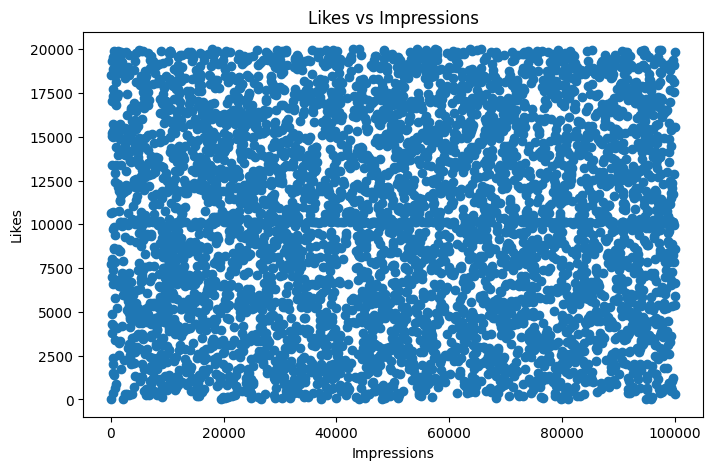

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["impression_count"],df["likes"])
plt.title("Likes vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.show()

**2 Line Chart**

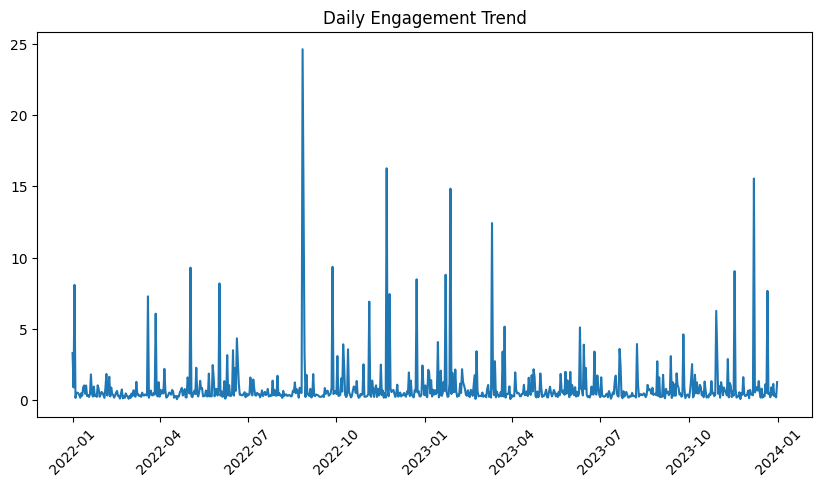

In [ ]:
daily=df.groupby(df["posted_at"].dt.date)["engagement_rate"].mean()

plt.figure(figsize=(10,5))
plt.plot(daily.index,daily.values)
plt.xticks(rotation=45)
plt.title("Daily Engagement Trend")
plt.show()

**3 Bar Chart**

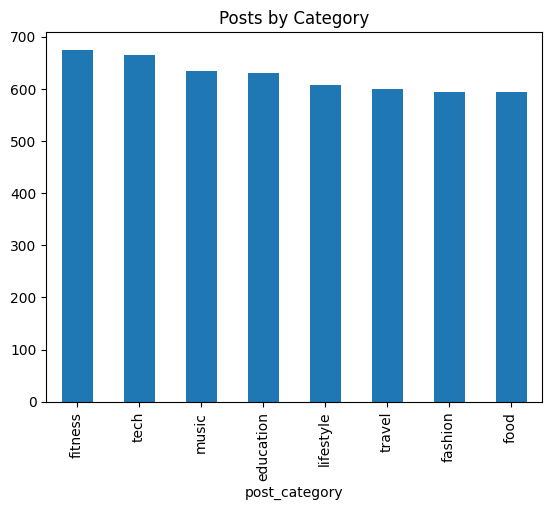

In [ ]:
df["post_category"].value_counts().plot(kind="bar")
plt.title("Posts by Category")
plt.show()

**4 Pie Chart**

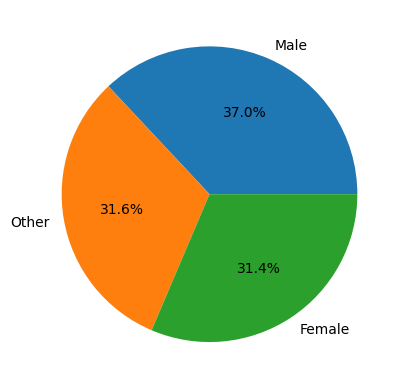

In [ ]:
df["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.show()

**5 Histogram**

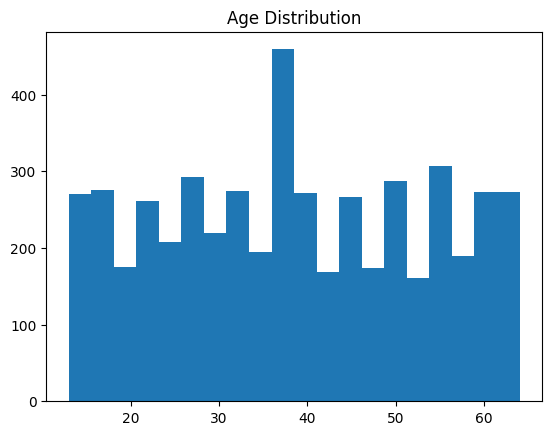

In [ ]:
plt.hist(df["age"],bins=20)
plt.title("Age Distribution")
plt.show()

**6 Box Plot**

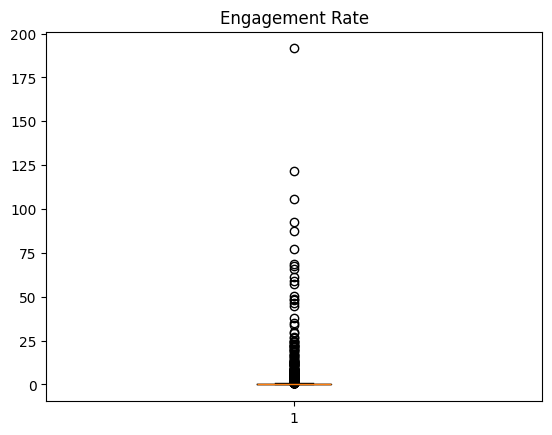

In [ ]:
plt.boxplot(df["engagement_rate"])
plt.title("Engagement Rate")
plt.show()

**7 Count Plot**

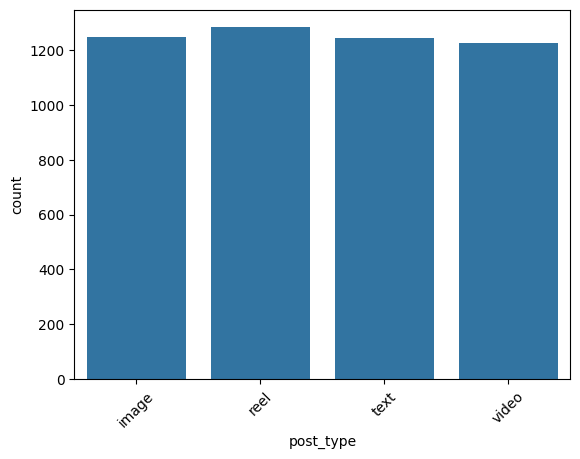

In [ ]:
sns.countplot(data=df,x="post_type")
plt.xticks(rotation=45)
plt.show()

**8 Bar Plot**

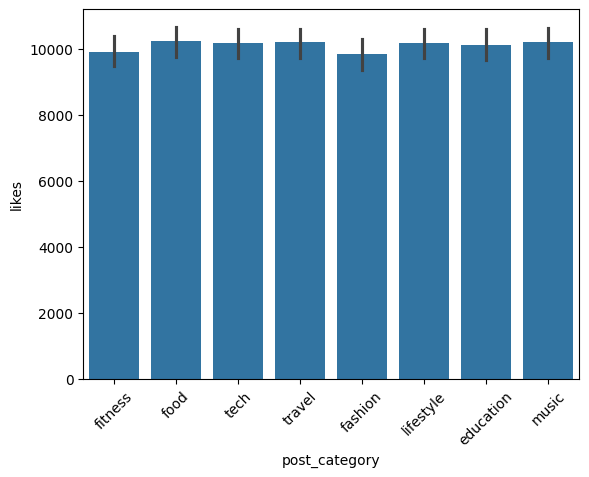

In [ ]:
sns.barplot(
    data=df,
    x="post_category",
    y="likes"
)
plt.xticks(rotation=45)
plt.show()

**9 Violin Plot**

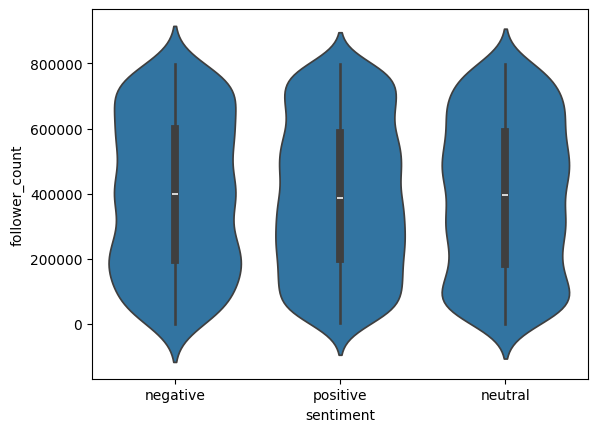

In [ ]:
sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)
plt.show()

**10 Pair Plot**

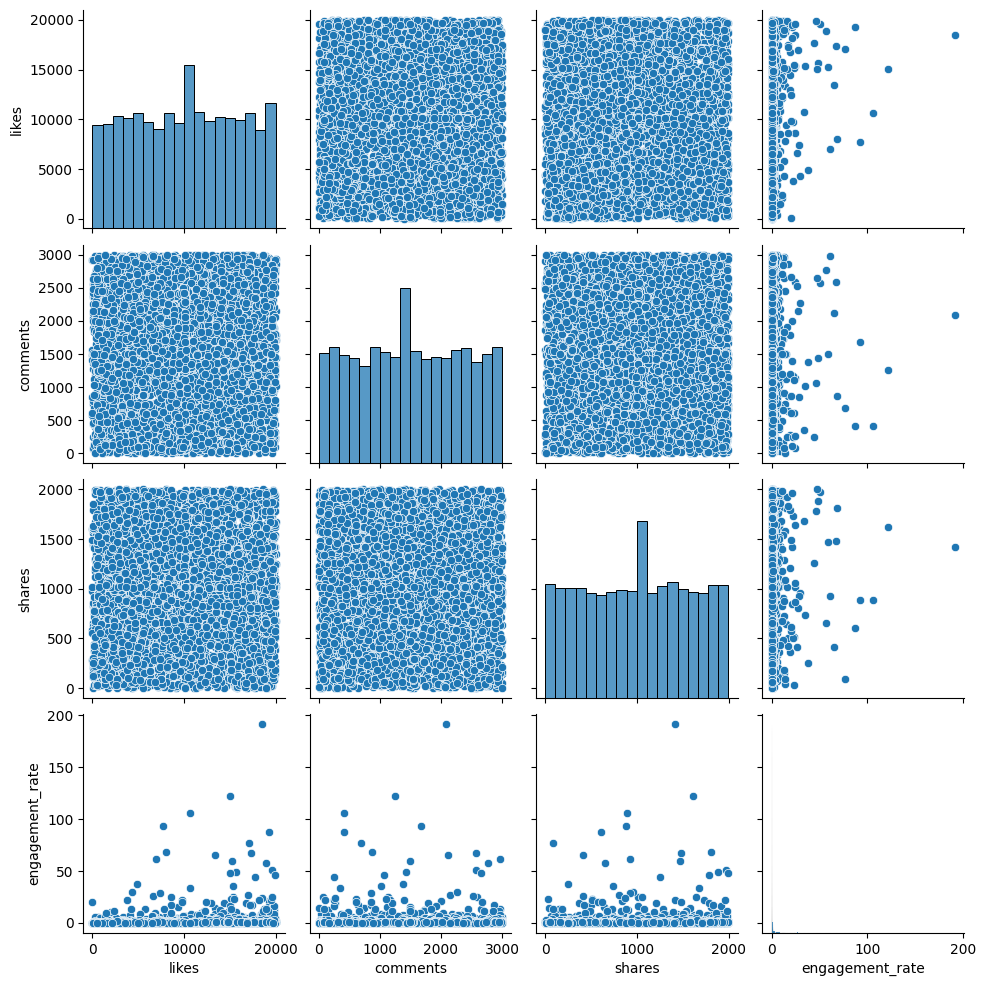

In [ ]:
sns.pairplot(
    df[
        [
            "likes",
            "comments",
            "shares",
            "engagement_rate"
        ]
    ]
)
plt.show()

**11 Heatmap**

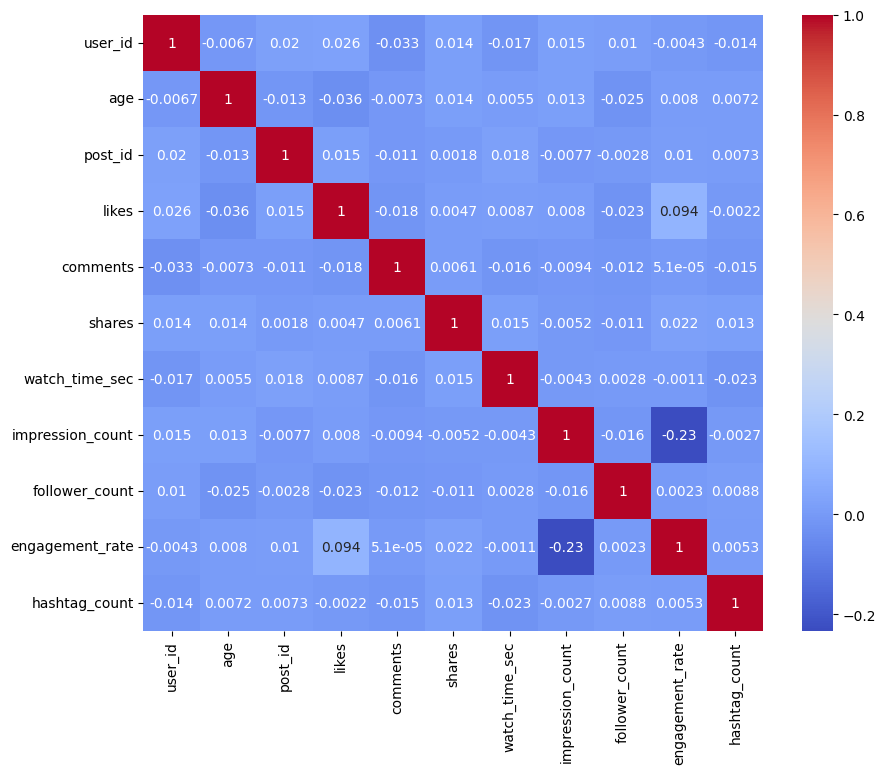

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

**12 Swarm Plot**

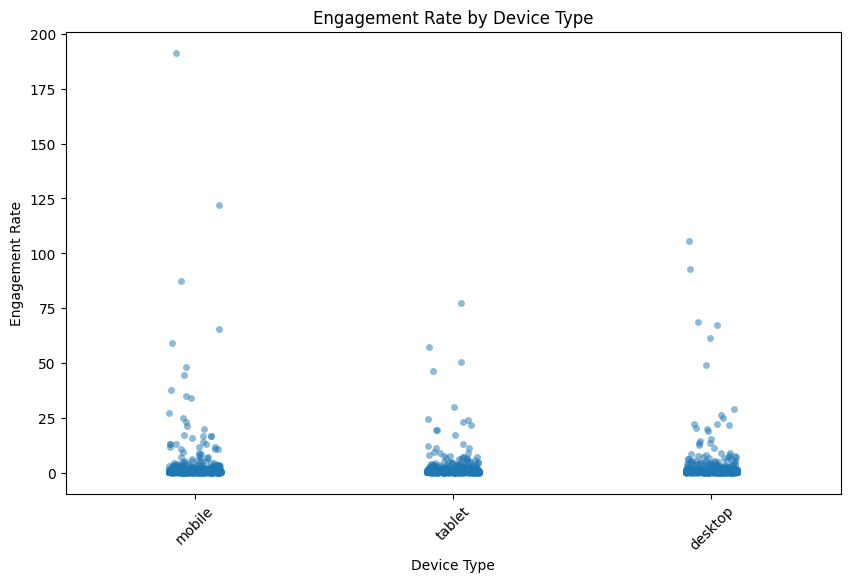

In [ ]:
plt.figure(figsize=(10,6))

sns.stripplot(
    data=df,
    x="device_type",
    y="engagement_rate",
    jitter=True,
    alpha=0.5
)

plt.title("Engagement Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)
plt.show()

**13 Plotly Interactive Chart**

In [ ]:
fig = px.scatter(
    df,
    x="likes",
    y="impression_count",
    color="post_category",
    size="engagement_rate",
    title="Interactive Engagement Analysis"
)

fig.show()

In [ ]:
print("\n========== FINAL INSIGHTS ==========")

print(f"Best Post Type : {df.groupby('post_type')['engagement_rate'].mean().idxmax()}")

print(f"Best Category : {df.groupby('post_category')['likes'].mean().idxmax()}")

print(f"Highest Engagement Country : {df.groupby('country')['engagement_rate'].mean().idxmax()}")

print(f"Average Age : {df['age'].mean():.2f}")

verified=df.groupby("is_verified")["engagement_rate"].mean()

print("\nVerified vs Non Verified")
print(verified)

print(f"\nBest Sentiment : {df.groupby('sentiment')['engagement_rate'].mean().idxmax()}")

print("===================================")


========== FINAL INSIGHTS ==========
Best Post Type : video
Best Category : food
Highest Engagement Country : Brazil
Average Age : 38.44

Verified vs Non Verified
is_verified
False    0.954744
True     1.054250
Name: engagement_rate, dtype: float64

Best Sentiment : negative
